/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc


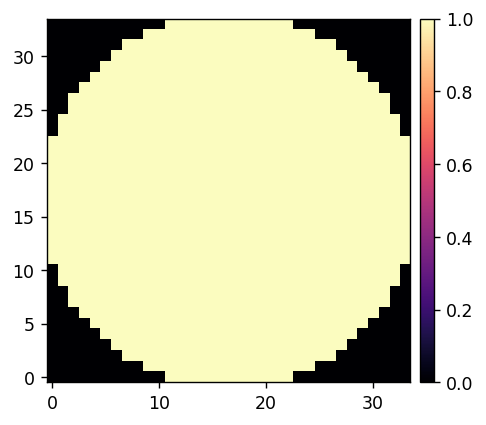

In [2]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

import scoob_llowfsc
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi

print(scoob_llowfsc.path)
data_path = scoob_llowfsc.path/'exp-data'

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])


In [3]:
camsci_name = 'camlo'
camlo_name = 'camsci'
dm_wfe_name = 'dm00disp01'
dm_lo_name = 'dm00disp02'
dm_ho_name = 'dm00disp03'

camlo_ref_name = 'camlo_ref_0'
camlo_ref_offset_name = 'camlo_ref_offset'

camsci_rawims_path = Path(f'/opt/MagAOX/rawimages/{camsci_name}/')
camlo_rawims_path = Path(f'/opt/MagAOX/rawimages/{camlo_name}/')
camlo_ref_rawims_path = Path(f'/opt/MagAOX/rawimages/{camlo_ref_name}/')
camlo_ref_offset_rawims_path = Path(f'/opt/MagAOX/rawimages/{camlo_ref_offset_name}/')
dm_wfe_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_wfe_name}/')
dm_lo_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_lo_name}/')
dm_ho_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_ho_name}/')

# date = 20250409
# date = 20250410
date = today
exp_path = data_path/f'exp-{date}'
telem_data_path = data_path/f'exp-{date}'/'raw-telem'
unpacked_data_path = data_path/f'exp-{date}'/'unpacked-telem'

In [4]:
telem.make_dir(exp_path)
telem.make_dir(telem_data_path)
telem.make_dir(unpacked_data_path)

Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250411' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250411/raw-telem' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250411/unpacked-telem' already exists.


In [40]:
reload(scoobi)
xc, yc = (3725, 2500)
npsf = 256
scoobi.set_cam_roi(xc, yc, npsf, client0, cam_name=camsci_name, bin_mode=2)
scoobi.set_cam_exp_time(0.001, client0, cam_name=camsci_name,)
scoobi.set_cam_gain(120, client0, cam_name=camsci_name,)
scoobi.set_cam_blacklevel(2, client0, cam_name=camsci_name,)

Set camlo ROI.
Set the camlo exposure time to 1.00e-03s
Set the camlo gain setting to 120.0
Set the camlo blacklevel to 2.0


In [42]:
xc, yc = (5450, 1100) # 1005, 1125
npsf = 128
scoobi.set_cam_roi(xc, yc, npsf, client0, cam_name=camlo_name, bin_mode=2)
scoobi.set_cam_exp_time(0.001, client0, cam_name=camlo_name,)
scoobi.set_cam_gain(120, client0, cam_name=camlo_name,)
scoobi.set_cam_blacklevel(1, client0, cam_name=camlo_name,)

Set camsci ROI.
Set the camsci exposure time to 1.00e-03s
Set the camsci gain setting to 120.0
Set the camsci blacklevel to 1.0


In [43]:
camsci_stream = ImageStream(camsci_name)
camlo_stream = ImageStream(camlo_name)
dm_wfe_stream = ImageStream(dm_wfe_name)
dm_lo_stream = ImageStream(dm_lo_name)
dm_ho_stream = ImageStream(dm_ho_name)

In [ ]:

import ImageStreamIOWrap as shmio

# camlo_dims = camlo_stream.shape[:-1]
camlo_dims = (128, 128)
print(camlo_dims)

# scoobi.create_shmim(camlo_ref_name, camlo_dims,)
# scoobi.create_shmim(camlo_ref_offset_name, camlo_dims,)
scoobi.create_shmim(camlo_ref_name, camlo_dims, dtype=shmio.ImageStreamIODataType.DOUBLE)
scoobi.create_shmim(camlo_ref_offset_name, camlo_dims, dtype= shmio.ImageStreamIODataType.DOUBLE)

camlo_ref_stream = ImageStream(camlo_ref_name)
camlo_ref_offset_stream = ImageStream(camlo_ref_offset_name)

(128, 128)


In [51]:
reload(telem)
telem.delete_files(camsci_rawims_path/'*.xrif')
telem.delete_files(camlo_rawims_path/'*.xrif')
telem.delete_files(camlo_ref_rawims_path/'*.xrif')
telem.delete_files(camlo_ref_offset_rawims_path/'*.xrif')
telem.delete_files(dm_wfe_rawims_path/'*.xrif')
telem.delete_files(dm_lo_rawims_path/'*.xrif')
telem.delete_files(dm_ho_rawims_path/'*.xrif')

telem.delete_files(telem_data_path/'*')
telem.delete_files(unpacked_data_path/'*')

In [52]:
telem.toggle(1, camsci_name, client0)
telem.toggle(1, camlo_name, client0)
telem.toggle(1, camlo_ref_name, client0)
telem.toggle(1, camlo_ref_offset_name, client0)
telem.toggle(1, dm_lo_name, client0)
telem.toggle(1, dm_ho_name, client0)

In [53]:
f_command = ensure_np_array(dm.make_f())
ring_command = ensure_np_array(dm.make_ring(rad=10))

for i in range(50):
    # camlo_ref_stream.write( np.random.randn(camlo_dims[0], camlo_dims[1]) )
    # camlo_ref_offset_stream.write( np.random.randn(camlo_dims[0], camlo_dims[1]) )
    camlo_ref_stream.write( i * np.ones(camlo_dims) )
    camlo_ref_offset_stream.write( 2*i * np.ones(camlo_dims) )
    dm_lo_stream.write(i*f_command)
    dm_ho_stream.write(i*ring_command)
    time.sleep(0.1)

# camlo_ref_stream.write(np.zeros(camlo_dims))
# camlo_ref_offset_stream.write(np.zeros(camlo_dims))
dm_lo_stream.write(np.zeros((34,34)))
dm_ho_stream.write(np.zeros((34,34)))


In [54]:
telem.toggle(0, camsci_name, client0)
telem.toggle(0, camlo_name, client0)
telem.toggle(0, camlo_ref_name, client0)
telem.toggle(0, camlo_ref_offset_name, client0)
telem.toggle(0, dm_lo_name, client0)
telem.toggle(0, dm_ho_name, client0)

In [55]:
telem.move_files(camsci_rawims_path, telem_data_path)
telem.move_files(camlo_rawims_path, telem_data_path)
telem.move_files(camlo_ref_rawims_path, telem_data_path)
telem.move_files(camlo_ref_offset_rawims_path, telem_data_path)
telem.move_files(dm_lo_rawims_path, telem_data_path)
telem.move_files(dm_ho_rawims_path, telem_data_path)

In [56]:
telem.unpack_data(telem_data_path, unpacked_data_path)

In [57]:
camsci_fnames = telem.get_fnames(unpacked_data_path/f'{camsci_name}_2025*')
camlo_fnames = telem.get_fnames(unpacked_data_path/f'{camlo_name}*')
camlo_ref_fnames = telem.get_fnames(unpacked_data_path/f'{camlo_ref_name}*')
camlo_ref_offset_fnames = telem.get_fnames(unpacked_data_path/f'{camlo_ref_offset_name}*')
dm_lo_fnames = telem.get_fnames(unpacked_data_path/f'{dm_lo_name}*')
dm_ho_fnames = telem.get_fnames(unpacked_data_path/f'{dm_ho_name}*')

In [58]:
camsci_fnames[-5:], camlo_fnames[-5:], camlo_ref_fnames[:5], camlo_ref_offset_fnames[:5], dm_lo_fnames[:5], dm_ho_fnames[:5]

(['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250411/unpacked-telem/camlo_20250411232532210990334.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250411/unpacked-telem/camlo_20250411232532217874927.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250411/unpacked-telem/camlo_20250411232532224717799.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250411/unpacked-telem/camlo_20250411232532231573523.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250411/unpacked-telem/camlo_20250411232532238436251.fits'],
 ['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250411/unpacked-telem/camsci_20250411232532224607960.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250411/unpacked-telem/camsci_20250411232532228772126.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250411/u

In [9]:
camlo_ref_offset_fnames[0], dm_lo_fnames[0]

('/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/camlo_ref_offset_20250411204326583997152.fits',
 '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/dm00disp02_20250411200509596111527.fits')

In [17]:
_, times1 = telem.read_telem_data([camlo_ref_offset_fnames[0]], absolute=1)
_, times2 = telem.read_telem_data([dm_lo_fnames[0]], absolute=1)
times1, times2, (times1-times2)/60

(array([74606.58399715]), array([72309.59611153]), array([38.28313143]))

In [60]:
camlo_ref_stream.write(20*np.random.randn(camlo_dims[0], camlo_dims[1]))

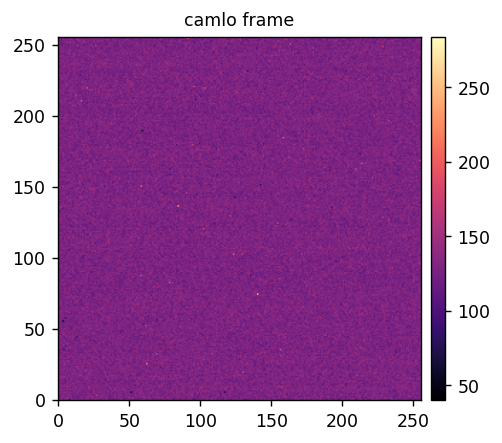

In [59]:
absolute = 1
camsci_data, camsci_times = telem.read_telem_data(camsci_fnames, absolute=absolute)
utils.imshow(
    [camsci_data[-1]],
    titles=[f'{camsci_name} frame'],
)
camsci_start = camsci_times[0]

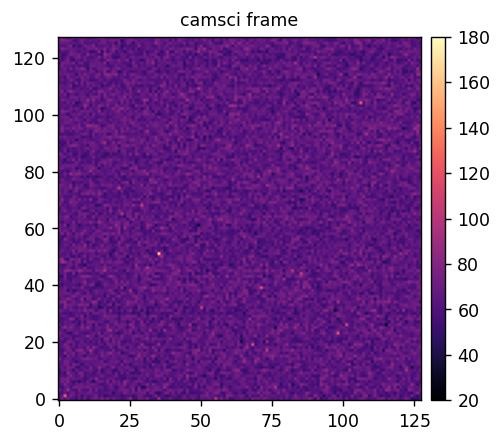

In [60]:
absolute = 1
camlo_data, camlo_times = telem.read_telem_data(camlo_fnames, absolute=absolute)
utils.imshow(
    [camlo_data[4]],
    titles=[f'{camlo_name} frame'],
)
camlo_start = camlo_times[0]

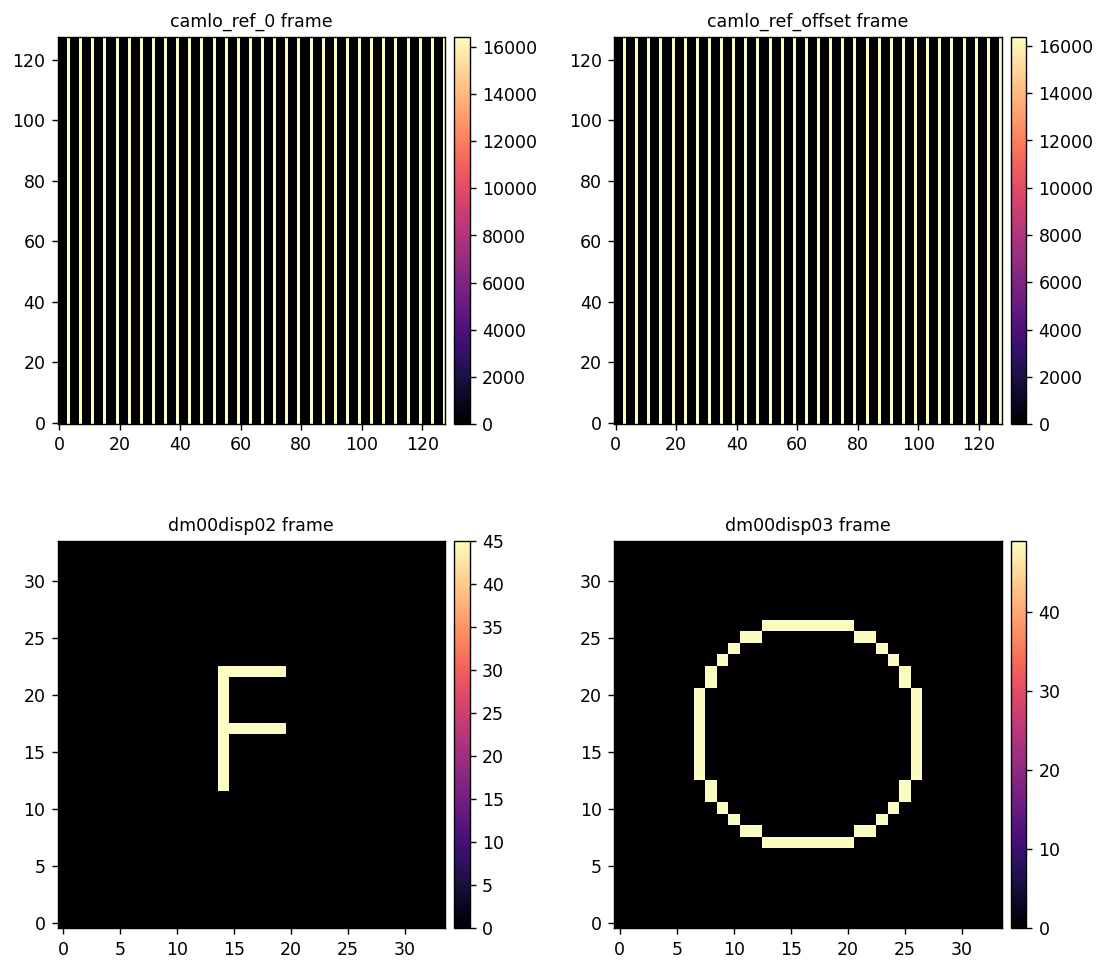

In [61]:
absolute = 1
camlo_ref_data, camlo_ref_times = telem.read_telem_data(camlo_ref_fnames, absolute=absolute)
camlo_ref_offset_data, camlo_ref_offset_times = telem.read_telem_data(camlo_ref_offset_fnames, absolute=absolute)
dm_lo_data, dm_lo_times = telem.read_telem_data(dm_lo_fnames, absolute=absolute)
dm_ho_data, dm_ho_times = telem.read_telem_data(dm_ho_fnames, absolute=absolute)

camlo_ref_start = camlo_ref_times[0]
camlo_ref_offset_start = camlo_ref_offset_times[0]
dm_lo_start = dm_lo_times[0]
dm_ho_start = dm_ho_times[0]

utils.imshow(
    [camlo_ref_data[-1], camlo_ref_offset_data[5], 
     dm_lo_data[40], dm_ho_data[-2]],
    titles=[f'{camlo_ref_name} frame',
            f'{camlo_ref_offset_name} frame',
            f'{dm_lo_name} frame',
            f'{dm_ho_name} frame'],
    figsize=(10,10),
    Nrows=2, Ncols=2,
    wspace=0.35, 
    hspace=0.1,
)


In [39]:
camlo_ref_data[-5].sum()

np.uint64(67264512)

In [32]:
2**14 + 128/2

16448.0

In [31]:
first_start = np.min([camsci_start, camlo_start, camlo_ref_start, camlo_ref_offset_start, dm_lo_start, dm_ho_start])

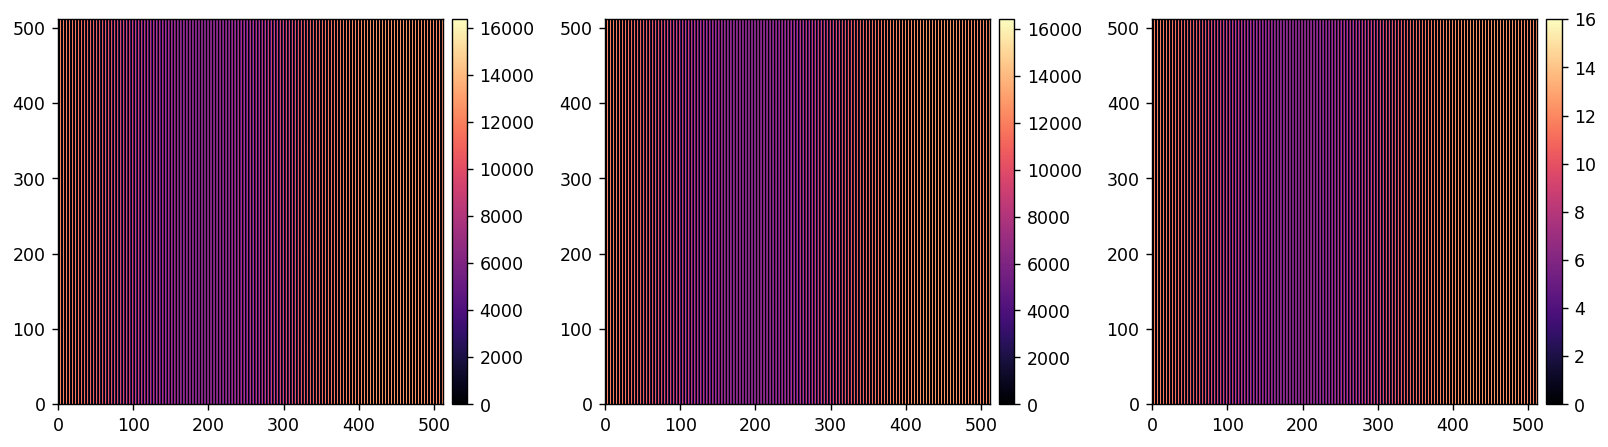

In [32]:
utils.imshow(
    [camlo_ref_data[0], camlo_ref_data[20], camlo_ref_data[20]-camlo_ref_data[10]],
)

Text(0.5, 1.0, 'dm00disp03 Times')

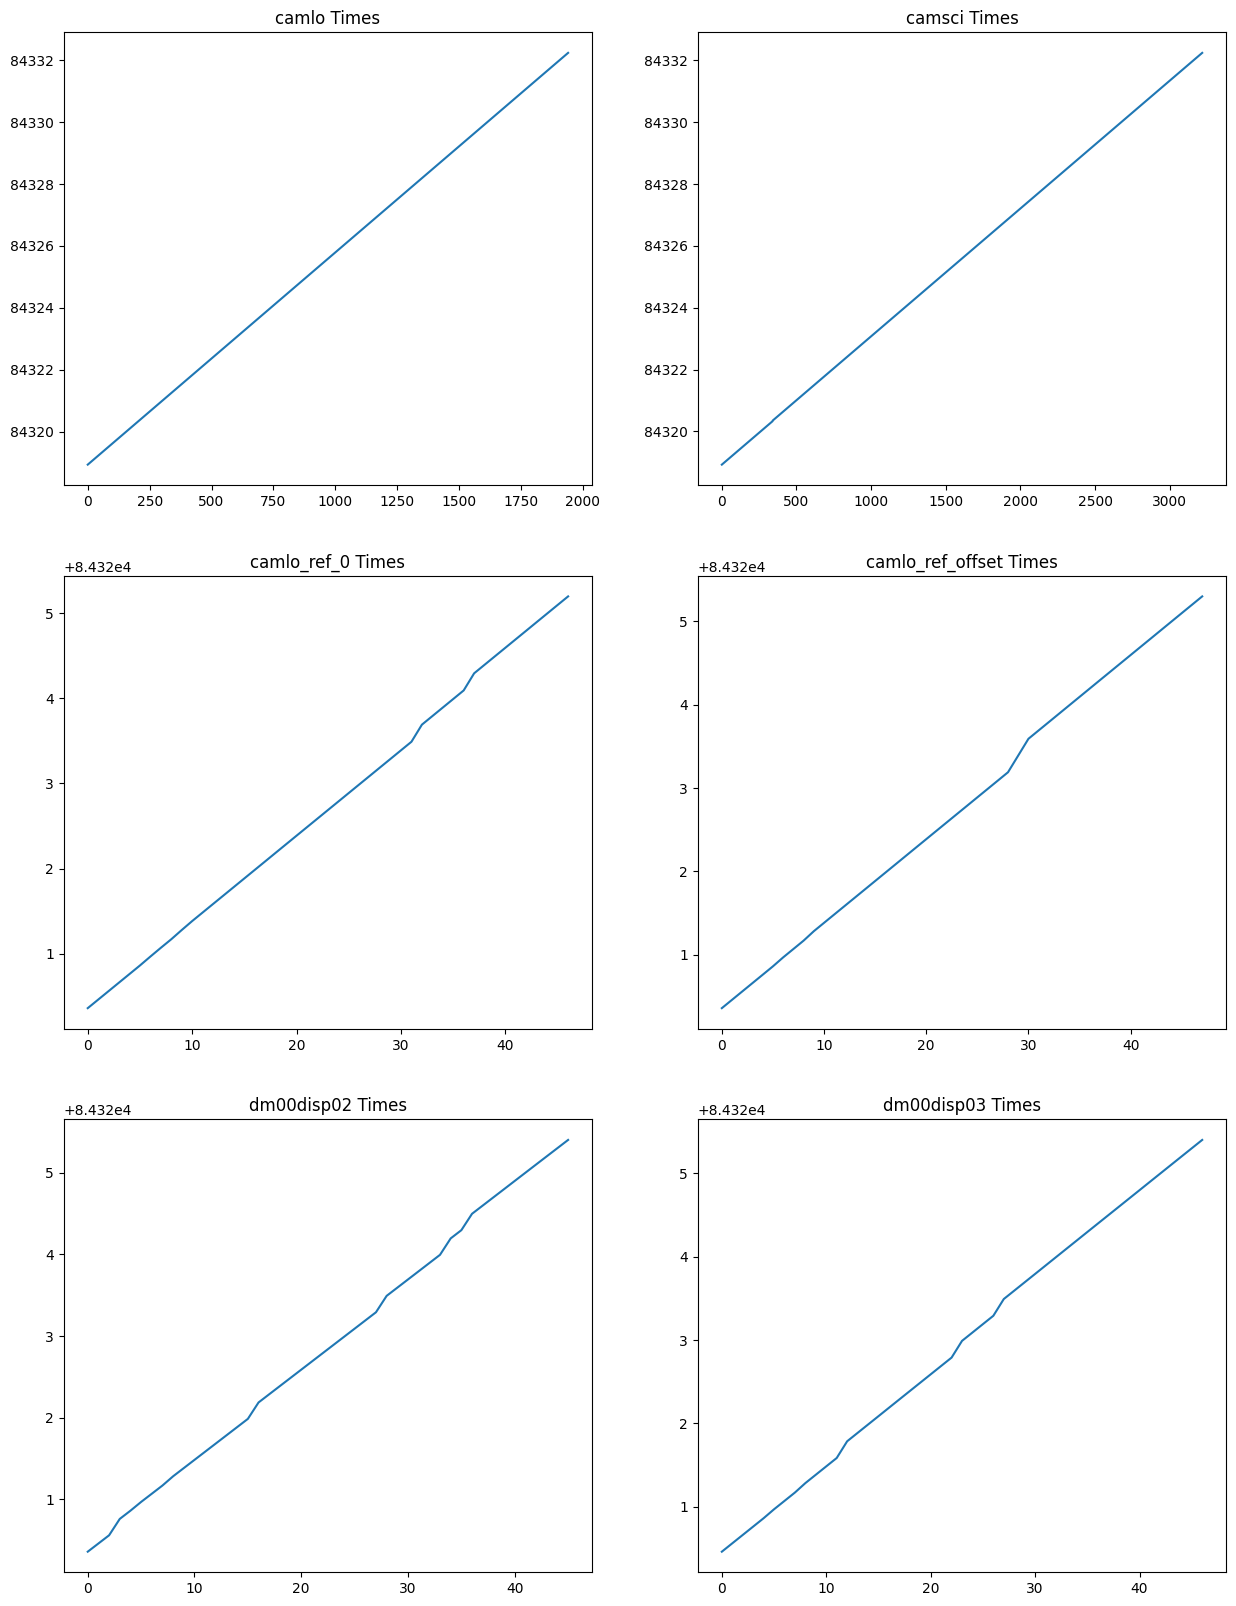

In [62]:
fig = plt.figure(figsize=(15,20))
plt.subplot(321)
plt.plot(camsci_times)
plt.title(f'{camsci_name} Times')

plt.subplot(322)
plt.plot(camlo_times)
plt.title(f'{camlo_name} Times')

plt.subplot(323)
plt.plot(camlo_ref_times[:-1])
plt.title(f'{camlo_ref_name} Times')

plt.subplot(324)
plt.plot(camlo_ref_offset_times)
plt.title(f'{camlo_ref_offset_name} Times')

plt.subplot(325)
plt.plot(dm_lo_times)
plt.title(f'{dm_lo_name} Times')

plt.subplot(326)
plt.plot(dm_ho_times)
plt.title(f'{dm_ho_name} Times')


(0.0, 48.3)

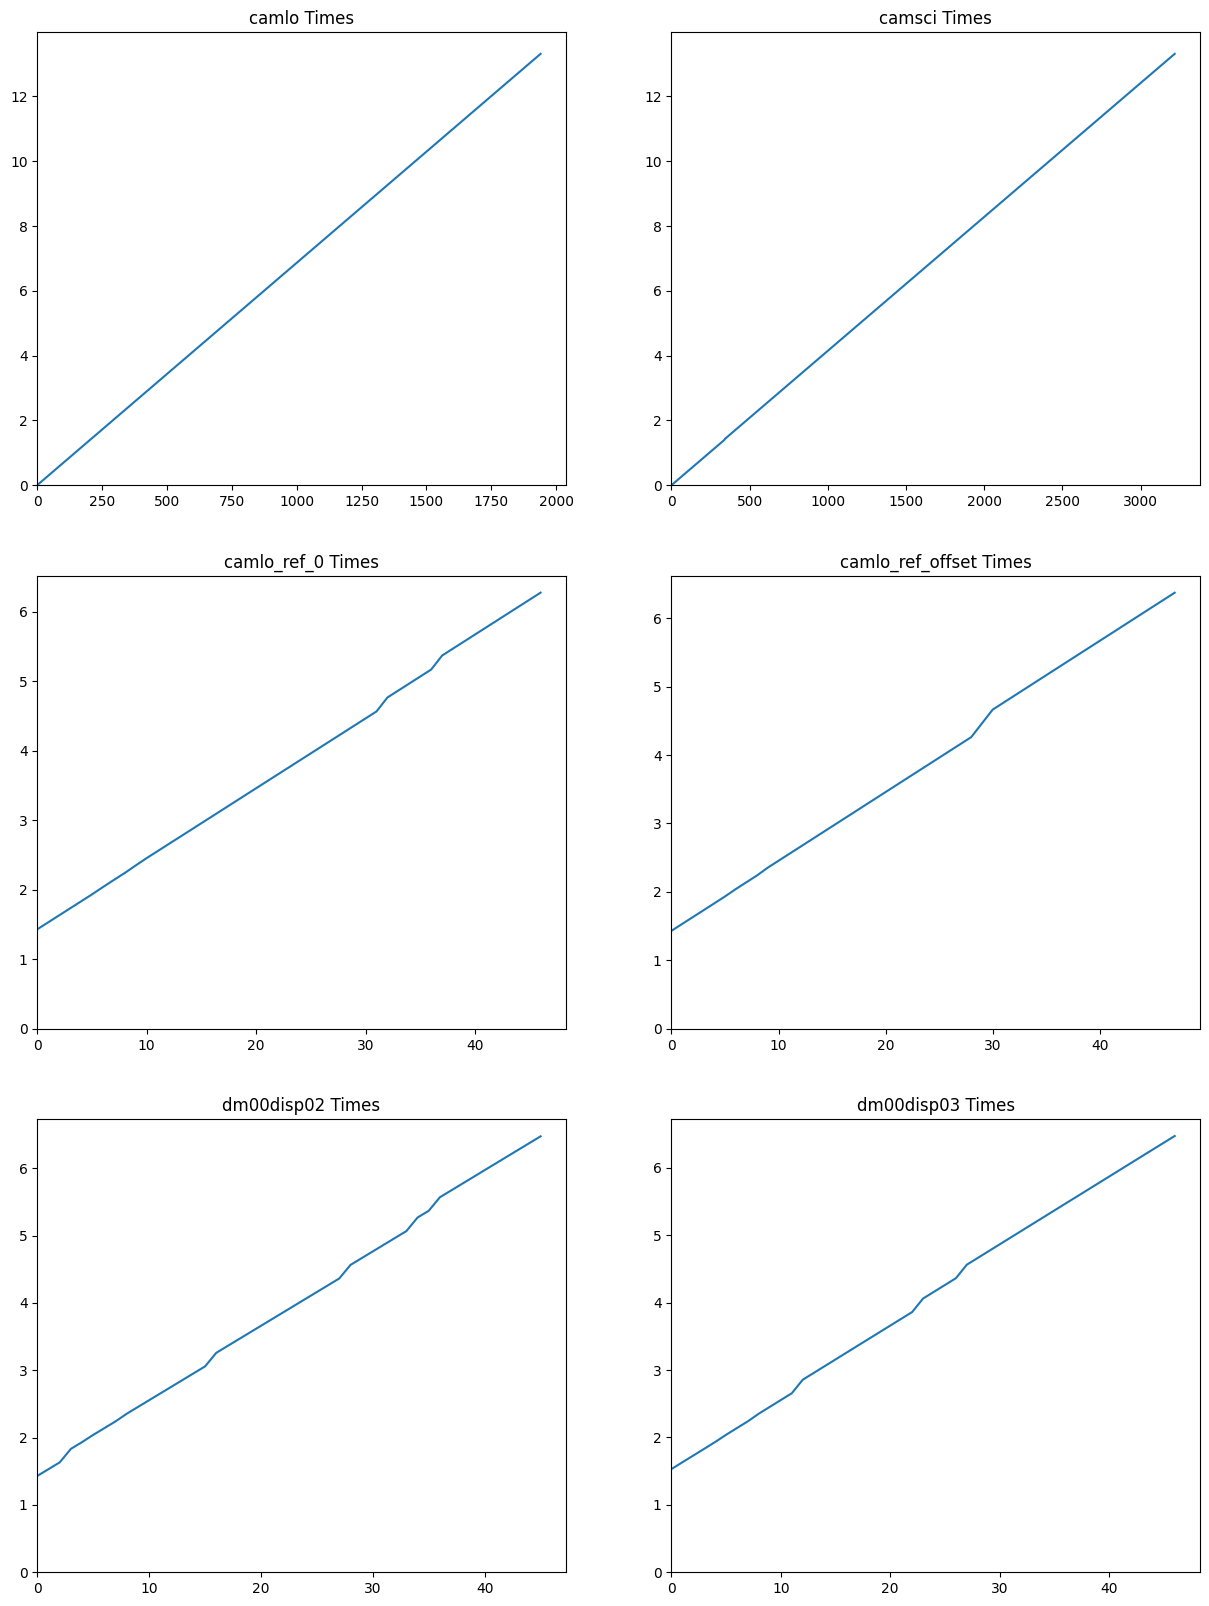

In [64]:
first_start = np.min([camsci_start, camlo_start, camlo_ref_start, camlo_ref_offset_start, dm_lo_start, dm_ho_start])

fig = plt.figure(figsize=(15,20))
plt.subplot(321)
plt.plot(camsci_times-first_start)
plt.title(f'{camsci_name} Times')
plt.ylim(0)
plt.xlim(0)

plt.subplot(322)
plt.plot(camlo_times-first_start)
plt.title(f'{camlo_name} Times')
plt.ylim(0)
plt.xlim(0)

plt.subplot(323)
plt.plot(camlo_ref_times[:-1]-first_start)
plt.title(f'{camlo_ref_name} Times')
plt.ylim(0)
plt.xlim(0)

plt.subplot(324)
plt.plot(camlo_ref_offset_times-first_start)
plt.title(f'{camlo_ref_offset_name} Times')
plt.ylim(0)
plt.xlim(0)

plt.subplot(325)
plt.plot(dm_lo_times-first_start)
plt.title(f'{dm_lo_name} Times')
plt.ylim(0)
plt.xlim(0)

plt.subplot(326)
plt.plot(dm_ho_times-first_start)
plt.title(f'{dm_ho_name} Times')
plt.ylim(0)
plt.xlim(0)

In [104]:
telem.delete_files(telem_data_path/'*')
telem.delete_files(unpacked_data_path/'*')